Pandas 데이터 재구조화(Reshaping) 함수

| 범주                | 함수                              | 설명                               |
| ----------------- | ------------------------------- | -------------------------------- |
|  **재구조화**       | `melt()`                        | wide → long (열을 행으로 변환)          |
|                   | `pivot()`                       | long → wide (열/행 구조로 변환, 중복 불가)  |
|                   | `pivot_table()`                 | 피벗 + 집계 기능 (중복 허용, `aggfunc` 가능) |
|  **스택/언스택**     | `stack()`                       | 열을 인덱스로 변환 (wide → long)         |
|                   | `unstack()`                     | 인덱스를 열로 변환 (long → wide)         |
|  **결합**         | `concat()`                      | 축 기준으로 데이터 연결 (row/column 방향)    |
|                   | `merge()`                       | SQL-style join (기준 key로 병합)      |
|                   | `join()`                        | 인덱스를 기준으로 병합 (merge 간단 버전)       |
|  **변환**         | `transpose()` or `.T`           | 행과 열 전치 (swap)                   |
| **슬라이스 및 재정렬** | `set_index()`, `reset_index()`  | 인덱스 설정 또는 해제                     |
|                   | `sort_values()`, `sort_index()` | 값 또는 인덱스 기준 정렬                   |



In [1]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
import platform

In [2]:

# OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')  # 윈도우: 맑은 고딕
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')    # 맥: 애플 고딕
else:
    plt.rc('font', family='NanumBarunGothic') # 리눅스

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

In [3]:
kmovies = pd.DataFrame({'MovieID':['1193','1194','1195'],
                        'Title':['디바','무림의 고수','정직한 후보'],
                        'Genres':['드라마','액션','코미디']})

kusers= pd.DataFrame({'UserID':[1,2,3,4,5],
                      'Gender':['F','M','M','F','M'],
                      'Age':[13,56,25,33,43]})

kratings= pd.DataFrame({'UserID':[1,1,1,2,2,2,3,3,3,4,4,4],
                        'MovieID':['1193','1194','1195','1193','1194','1195','1193','1194','1195','1193','1194','1195'],
                        'Rating':[2,5,None,3,1,5,None,2,5,5,None,3]})

In [4]:
print(type(kmovies))

<class 'pandas.DataFrame'>


In [5]:
kmovies

,MovieID,Title,Genres
0,1193,디바,드라마
1,1194,무림의 고수,액션
2,1195,정직한 후보,코미디


In [6]:
kusers

,UserID,Gender,Age
0,1,F,13
1,2,M,56
2,3,M,25
3,4,F,33
4,5,M,43


In [7]:
kratings

,UserID,MovieID,Rating
0,1,1193,2.0
1,1,1194,5.0
2,1,1195,NaN
3,2,1193,3.0
4,2,1194,1.0
5,2,1195,5.0
6,3,1193,NaN
7,3,1194,2.0
8,3,1195,5.0
9,4,1193,5.0


```
판다스의 merge() 함수는 기본값(how='inner')으로 inner join을 수행한다.
다만 how 매개변수를 바꾸어 left, right, outer join 등 다른 방식으로도 동작할 수 있다.

Merge 함수의 주요 종류 (how 매개변수)
inner: 양쪽 데이터프레임에 모두 공통으로 존재하는 키 값만 남긴다.(기본값)
left: 왼쪽 데이터프레임의 모든 행을 남기고 오른쪽은 일치하는 값만 연결한다.
right: 오른쪽 데이터프레임의 모든 행을 남기고 왼쪽은 일치하는 값만 연결한다.
outer: 양쪽 데이터프레임의 모든 행을 남기고 비어 있는 곳은 NaN으로 채운다.
```

In [8]:
# merge: DataFrame 병합
# 판다스의 merge() 함수는 기본값(how='inner')으로 inner join을 수행
kdata = kratings.merge(kusers).merge(kmovies)
kdata

,UserID,MovieID,Rating,Gender,Age,Title,Genres
0,1,1193,2.0,F,13,디바,드라마
1,1,1194,5.0,F,13,무림의 고수,액션
2,1,1195,NaN,F,13,정직한 후보,코미디
3,2,1193,3.0,M,56,디바,드라마
4,2,1194,1.0,M,56,무림의 고수,액션
5,2,1195,5.0,M,56,정직한 후보,코미디
6,3,1193,NaN,M,25,디바,드라마
7,3,1194,2.0,M,25,무림의 고수,액션
8,3,1195,5.0,M,25,정직한 후보,코미디
9,4,1193,5.0,F,33,디바,드라마


In [9]:
krecom_data = kdata[['UserID', 'MovieID', 'Rating']]
krecom_data

,UserID,MovieID,Rating
0,1,1193,2.0
1,1,1194,5.0
2,1,1195,NaN
3,2,1193,3.0
4,2,1194,1.0
5,2,1195,5.0
6,3,1193,NaN
7,3,1194,2.0
8,3,1195,5.0
9,4,1193,5.0


### pivot
- 각 컬럼의 값을 교차테이블 구성요소로 전달, 교차테이블 완성
- index, columns, values 컬럼을 각각 전달
- 요약기능 없음
-dataframe.pivot(index, columns, values)


In [10]:
krecom_pivot =   krecom_data.pivot(index='UserID', columns='MovieID', values='Rating')
print(type(krecom_pivot))
print(krecom_pivot.columns)
print(krecom_pivot.index)
print(krecom_pivot.values)
print(type(krecom_pivot.values))
krecom_pivot


<class 'pandas.DataFrame'>
Index(['1193', '1194', '1195'], dtype='str', name='MovieID')
Index([1, 2, 3, 4], dtype='int64', name='UserID')
[[ 2.  5. nan]
 [ 3.  1.  5.]
 [nan  2.  5.]
 [ 5. nan  3.]]
<class 'numpy.ndarray'>


MovieID,1193,1194,1195
UserID,,,
1,2.0,5.0,NaN
2,3.0,1.0,5.0
3,NaN,2.0,5.0
4,5.0,NaN,3.0


In [11]:
# 앞의 값으로 뒤의 Nan을 채워준다.
#krecom_pivot.fillna(method='ffill')
#krecom_pivot.fillna(method='pad')

# 뒤의 갑으로 앞의  Nan을 채워준다.
#krecom_pivot.fillna(method='bfill')
#krecom_pivot.fillna(method='backfill')


#krecom_pivot.fillna(krecom_pivot.mean(), axis=0)
#krecom_pivot.fillna(0)
krecom_pivot.fillna(krecom_pivot.max(), axis=0)


MovieID,1193,1194,1195
UserID,,,
1,2.0,5.0,5.0
2,3.0,1.0,5.0
3,5.0,2.0,5.0
4,5.0,5.0,3.0


In [12]:
krecom_pivot.fillna(krecom_pivot.mean(), axis=0, inplace=True)
krecom_pivot

MovieID,1193,1194,1195
UserID,,,
1,2.000000,5.000000,4.333333
2,3.000000,1.000000,5.000000
3,3.333333,2.000000,5.000000
4,5.000000,2.666667,3.000000


In [13]:
krecom_pivot_table = krecom_data.pivot_table(index='UserID', columns='MovieID', values='Rating',
                                             aggfunc={'Rating':np.mean}, fill_value=0)
krecom_pivot_table

MovieID,1193,1194,1195
UserID,,,
1,2.0,5.0,0.0
2,3.0,1.0,5.0
3,0.0,2.0,5.0
4,5.0,0.0,3.0


In [14]:
df = pd.DataFrame({'A':['foo', 'foo', 'foo', 'foo', 'foo', 'bar', 'bar', 'bar', 'bar'],
                    'B':['one', 'one', 'one', 'two', 'two', 'one', 'one', 'two', 'tow'],
                    'C':['small', 'large', 'large', 'small', 'small', 'large', 'small', 'small', 'large'],
                    'D':[1, 2, 2, 3, 3, 4, 5, 6, 7],
                    'E':[2, 4, 5, 5, 6, 6, 8, 9, 9]})
df

,A,B,C,D,E
0,foo,one,small,1,2
1,foo,one,large,2,4
2,foo,one,large,2,5
3,foo,two,small,3,5
4,foo,two,small,3,6
5,bar,one,large,4,6
6,bar,one,small,5,8
7,bar,two,small,6,9
8,bar,tow,large,7,9


In [15]:
table = pd.pivot_table(df, index=['A','C'], values=['D','E'])
print(table.columns)
print(table.index)
print(table.values)
table

Index(['D', 'E'], dtype='str')
MultiIndex([('bar', 'large'),
            ('bar', 'small'),
            ('foo', 'large'),
            ('foo', 'small')],
           names=['A', 'C'])
[[5.5        7.5       ]
 [5.5        8.5       ]
 [2.         4.5       ]
 [2.33333333 4.33333333]]


D         E
A   C                        
bar large  5.500000  7.500000
    small  5.500000  8.500000
foo large  2.000000  4.500000
    small  2.333333  4.333333

In [16]:
table = pd.pivot_table(df, index=['A','C'], values=['D','E'], aggfunc={'D':np.mean,'E':[min, max, np.mean]})
print(table.columns)
print(table.index)
print(table.values)
table

MultiIndex([('D', 'mean'),
            ('E',  'max'),
            ('E', 'mean'),
            ('E',  'min')],
           )
MultiIndex([('bar', 'large'),
            ('bar', 'small'),
            ('foo', 'large'),
            ('foo', 'small')],
           names=['A', 'C'])
[[5.5        9.         7.5        6.        ]
 [5.5        9.         8.5        8.        ]
 [2.         5.         4.5        4.        ]
 [2.33333333 6.         4.33333333 2.        ]]


D   E              
               mean max      mean min
A   C                                
bar large  5.500000   9  7.500000   6
    small  5.500000   9  8.500000   8
foo large  2.000000   5  4.500000   4
    small  2.333333   6  4.333333   2

In [17]:
a = np.array([5, 8, 9, 2])
print(np.min(a)) # 최소값
print(np.max(a)) # 최대값
print(np.argmin(a)) # 최소값이 있는 위치를(인덱스) 리턴
print(np.argmax(a)) # 최대값이 있는 위치를(인덱스) 리턴

2
9
3
2


### pandas.melt()
pandas.melt()는 데이터를 **넓은 형식(wide format)**에서 **긴 형식(long format)**으로 변환할때 사용한다. 즉, 즉, 열(column)을 행(row)으로 "변환하는(melt)" 함수이다.

pandas.melt() 기본 개념
```
pd.melt(frame, id_vars=None, value_vars=None, var_name=None, value_name='value', ...)
```

주요 파라미터 설명  

| 인자명          | 설명                          |
| ------------ | --------------------------- |
| `frame`      | 재구조화할  데이터프레임                  |
| `id_vars`    | 변환되지 않고 그대로 유지할 열 (고정 컬럼)         |
| `value_vars` | 변환할  컬럼 지정 (지정하지 않으면 id_vars를 제외한 모든 컬럼이 선택됨 )|
| `var_name`   | 변환할 컬럼 이름(기존 컬럼명들이 저장될 컬럼 이름) |
| `value_name` | 변환할 값 이름(기존 값들이 저장될 컬럼 이름)   |

melt vs pivot

| 목적     | 함수                         | 설명                 |
| ------ | -------------------------- | ------------------ |
| 넓은 → 긴 | `melt()`                   | 여러 컬럼을 하나의 컬럼으로 변환 |
| 긴 → 넓은 | `pivot()`, `pivot_table()` | 변환 데이터를 다시 원래대로 펼침 |



In [18]:
import pandas as pd

# 원본 데이터 (넓은 형식)
df = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Steven'],
    'math': [90, 85, 78],
    'english': [95, 80, 88],
    'science': [85, 78, 92],
})

df

,student,math,english,science
0,Alice,90,95,85
1,Bob,85,80,78
2,Steven,78,88,92


In [19]:
# melted = df.melt(id_vars='student')
# melted = pd.melt(df, id_vars='student', var_name='subject', value_name= 'score')
melted = df.melt(id_vars='student', var_name='subject', value_name= 'score')

melted

,student,subject,score
0,Alice,math,90
1,Bob,math,85
2,Steven,math,78
3,Alice,english,95
4,Bob,english,80
5,Steven,english,88
6,Alice,science,85
7,Bob,science,78
8,Steven,science,92


In [20]:
pivoted = melted.pivot(index='student', columns='subject', values='score').reset_index()
print(pivoted.columns)

pivoted = pivoted.drop(columns='student')
pivoted.columns.name = None
print(pivoted.columns)
pivoted

Index(['student', 'english', 'math', 'science'], dtype='str', name='subject')
Index(['english', 'math', 'science'], dtype='str')


,english,math,science
0,95,90,85
1,80,85,78
2,88,78,92


In [21]:
# pivot()으로 다시 넓은 형식으로 되돌리기
pivoted = melted.pivot(index='student', columns='subject', values='score').reset_index()
print(pivoted.columns)
print(pivoted)
print("------------------------------------------")
pivoted = pivoted.drop(columns='student')
print(pivoted.columns)
print(pivoted)
print("------------------------------------------")
# subject이 컬럼으로 변환할때 기존 컬럼 이름이 name='subject' 이 된다.
# subject을 삭제하기 위해서 pivoted.columns.name=None 을 실행한다.
pivoted.columns.name=None
print(pivoted.columns)
pivoted


Index(['student', 'english', 'math', 'science'], dtype='str', name='subject')
subject student  english  math  science
0         Alice       95    90       85
1           Bob       80    85       78
2        Steven       88    78       92
------------------------------------------
Index(['english', 'math', 'science'], dtype='str', name='subject')
subject  english  math  science
0             95    90       85
1             80    85       78
2             88    78       92
------------------------------------------
Index(['english', 'math', 'science'], dtype='str')


,english,math,science
0,95,90,85
1,80,85,78
2,88,78,92


In [22]:
# pivot_table()을 활용한 평균 구하기
                                                                                    # aggfunc=np.mean
pivoted_table = melted.pivot_table(index='student', columns='subject', values='score', aggfunc='mean').reset_index()
print(pivoted_table)
print("-------------------------------------------------------")
pivoted_table = pivoted_table.drop(columns='student')
pivoted_table.columns.name=None
pivoted_table

subject student  english  math  science
0         Alice     95.0  90.0     85.0
1           Bob     80.0  85.0     78.0
2        Steven     88.0  78.0     92.0
-------------------------------------------------------


,english,math,science
0,95.0,90.0,85.0
1,80.0,85.0,78.0
2,88.0,78.0,92.0


학년별 평균점수, 성별/과목별 분석, 시간 흐름에 따른 값 실전 분석 패턴

| 분석 유형     | 핵심 도구                                         |
| --------- | --------------------------------------------- |
| 학년별 평균 분석 | `groupby()` + `pivot_table()`                 |
| 성별/과목별 비교 | `melt()` + `pivot_table()`                    |
| 시계열 분석    | `groupby(['year', 'subject'])` + `lineplot()` |

1. 학년별 평균점수 분석

In [23]:
# ①데이터 생성
import pandas as pd

df = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank'],
    'grade': [1, 1, 2, 2, 3, 3],
    'math': [90, 85, 78, 82, 70, 95],
    'english': [95, 80, 88, 76, 85, 90],
    'science': [85, 78, 92, 88, 75, 98]
})

df


,student,grade,math,english,science
0,Alice,1,90,95,85
1,Bob,1,85,80,78
2,Charlie,2,78,88,92
3,David,2,82,76,88
4,Eva,3,70,85,75
5,Frank,3,95,90,98


In [24]:
df.groupby("grade").sum()
df

,student,grade,math,english,science
0,Alice,1,90,95,85
1,Bob,1,85,80,78
2,Charlie,2,78,88,92
3,David,2,82,76,88
4,Eva,3,70,85,75
5,Frank,3,95,90,98


In [25]:
melted = pd.melt(df, id_vars=['grade'])
melted

,grade,variable,value
0,1,student,Alice
1,1,student,Bob
2,2,student,Charlie
3,2,student,David
4,3,student,Eva
5,3,student,Frank
6,1,math,90
7,1,math,85
8,2,math,78
9,2,math,82


In [26]:
# ②  melt()
melted = pd.melt(df, id_vars=['grade'], value_vars=['math', 'english', 'science'], var_name='subject', value_name='score')
melted

,grade,subject,score
0,1,math,90
1,1,math,85
2,2,math,78
3,2,math,82
4,3,math,70
5,3,math,95
6,1,english,95
7,1,english,80
8,2,english,88
9,2,english,76


In [27]:
# ③ pivot_table
grade_avg = melted.pivot_table(index='grade', columns='subject', values='score', aggfunc='mean').reset_index()
grade_avg.columns.name=None
print(grade_avg.columns)
print("----------------------------------------------------------")
grade_avg

Index(['grade', 'english', 'math', 'science'], dtype='str')
----------------------------------------------------------


,grade,english,math,science
0,1,87.5,87.5,81.5
1,2,82.0,80.0,90.0
2,3,87.5,82.5,86.5


2. 성별 / 과목별 평균 분석

In [28]:
# 성별 컬럼 추가
df['gender'] = ['F', 'M', 'M', 'M', 'F', 'M']
df

,student,grade,math,english,science,gender
0,Alice,1,90,95,85,F
1,Bob,1,85,80,78,M
2,Charlie,2,78,88,92,M
3,David,2,82,76,88,M
4,Eva,3,70,85,75,F
5,Frank,3,95,90,98,M


In [29]:
# ②  melt()
melted = pd.melt(df, id_vars=['gender'], value_vars=['math', 'english', 'science'], var_name='subject', value_name='score')
#print(melted)

# ③ pivot_table
gender_avg = melted.pivot_table(index=['gender'], columns='subject', values='score', aggfunc='mean').reset_index()
gender_avg.columns.name=None
print(gender_avg.columns)
print(gender_avg)

Index(['gender', 'english', 'math', 'science'], dtype='str')
  gender  english  math  science
0      F     90.0  80.0     80.0
1      M     83.5  85.0     89.0


3. 학년별 ,성별/과목별 분석

In [36]:
# ②  melt()
melted = pd.melt(df, id_vars=['grade','gender'], value_vars=['math', 'english', 'science'], var_name='subject', value_name='score')
# print(melted)

# ③ pivot_table
grade_gender_avg = melted.pivot_table(index=['grade','gender'], columns='subject', values='score', aggfunc='mean').reset_index()
grade_gender_avg.columns.name=None
print(grade_gender_avg.columns)
grade_gender_avg

Index(['grade', 'gender', 'english', 'math', 'science'], dtype='str')


,grade,gender,english,math,science
0,1,F,95.0,90.0,85.0
1,1,M,80.0,85.0,78.0
2,2,M,82.0,80.0,90.0
3,3,F,85.0,70.0,75.0
4,3,M,90.0,95.0,98.0


4. 시간 흐름에 따른 점수 변화 분석(시계열)

In [31]:
df['year']= [2023, 2024, 2023, 2024, 2023, 2024]
df

,student,grade,math,english,science,gender,year
0,Alice,1,90,95,85,F,2023
1,Bob,1,85,80,78,M,2024
2,Charlie,2,78,88,92,M,2023
3,David,2,82,76,88,M,2024
4,Eva,3,70,85,75,F,2023
5,Frank,3,95,90,98,M,2024


In [41]:
melted_time = pd.melt(df, id_vars=['student', 'year'], value_vars=['math', 'english', 'science'], var_name='subject', value_name='score' )
print(melted_time)
print("------------------------------------------------------------------------")

time_avg = melted_time.groupby(['year', 'subject'])['score'].mean().reset_index()
time_avg

    student  year  subject  score
0     Alice  2023     math     90
1       Bob  2024     math     85
2   Charlie  2023     math     78
3     David  2024     math     82
4       Eva  2023     math     70
5     Frank  2024     math     95
6     Alice  2023  english     95
7       Bob  2024  english     80
8   Charlie  2023  english     88
9     David  2024  english     76
10      Eva  2023  english     85
11    Frank  2024  english     90
12    Alice  2023  science     85
13      Bob  2024  science     78
14  Charlie  2023  science     92
15    David  2024  science     88
16      Eva  2023  science     75
17    Frank  2024  science     98
------------------------------------------------------------------------


,year,subject,score
0,2023,english,89.333333
1,2023,math,79.333333
2,2023,science,84.000000
3,2024,english,82.000000
4,2024,math,87.333333
5,2024,science,88.000000


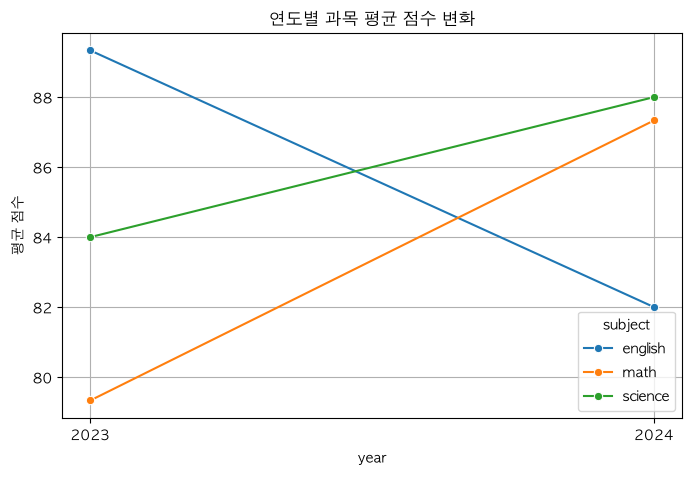

In [33]:
# 시각화
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.lineplot(data=time_avg, x='year', y='score', hue='subject', marker='o')
plt.title("연도별 과목 평균 점수 변화")
plt.ylabel("평균 점수")
plt.xticks([2023, 2024])
plt.grid(True)
plt.show()
